# Importar cosas

In [5]:
import tensorflow as tf
import sklearn
import pandas as pd

def check_environment():
    report = {
        "TensorFlow Version": tf.__version__,
        "Scikit-Learn Version": sklearn.__version__,
        "Pandas Version": pd.__version__,
        "GPU Available": tf.config.list_physical_devices('GPU') != []
    }
    
    print("--- Environment Status Report ---")
    for key, value in report.items():
        print(f"{key}: {value}")

check_environment()

--- Environment Status Report ---
TensorFlow Version: 2.21.0
Scikit-Learn Version: 1.8.0
Pandas Version: 3.0.2
GPU Available: False


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,GRU, Dense, Bidirectional
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.layers import TimeDistributed, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Cargar datos

In [7]:
df = pd.read_csv("electricityConsumptionAndProductioction.csv")
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [8]:
df.describe()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000
mean,6475.453288,6305.888155,1278.135886,761.555994,1756.517895,1169.512530,1087.092262,193.314074,54.577615
std,1062.464918,1041.573099,240.519134,660.501135,672.162325,441.780043,337.683509,302.883468,13.642238
min,2542.000000,2818.000000,562.000000,-26.000000,175.000000,146.000000,220.000000,0.000000,6.000000
25%,5651.000000,5561.000000,1332.000000,225.000000,1254.000000,859.000000,836.000000,0.000000,45.000000
50%,6411.000000,6254.000000,1370.000000,564.000000,1654.000000,1210.000000,1045.000000,4.000000,55.000000
75%,7230.000000,6999.000000,1396.000000,1146.000000,2153.000000,1527.000000,1311.000000,326.000000,65.000000
max,11986.000000,12179.000000,2081.000000,2811.000000,4434.000000,2770.000000,2537.000000,2331.000000,91.000000


In [9]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')
df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [10]:
df.describe()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000
mean,6475.453288,6305.888155,1278.135886,761.555994,1756.517895,1169.512530,1087.092262,193.314074,54.577615
std,1062.464918,1041.573099,240.519134,660.501135,672.162325,441.780043,337.683509,302.883468,13.642238
min,2542.000000,2818.000000,562.000000,-26.000000,175.000000,146.000000,220.000000,0.000000,6.000000
25%,5651.000000,5561.000000,1332.000000,225.000000,1254.000000,859.000000,836.000000,0.000000,45.000000
50%,6411.000000,6254.000000,1370.000000,564.000000,1654.000000,1210.000000,1045.000000,4.000000,55.000000
75%,7230.000000,6999.000000,1396.000000,1146.000000,2153.000000,1527.000000,1311.000000,326.000000,65.000000
max,11986.000000,12179.000000,2081.000000,2811.000000,4434.000000,2770.000000,2537.000000,2331.000000,91.000000


# Graficar visualmente

<Axes: xlabel='DateTime'>

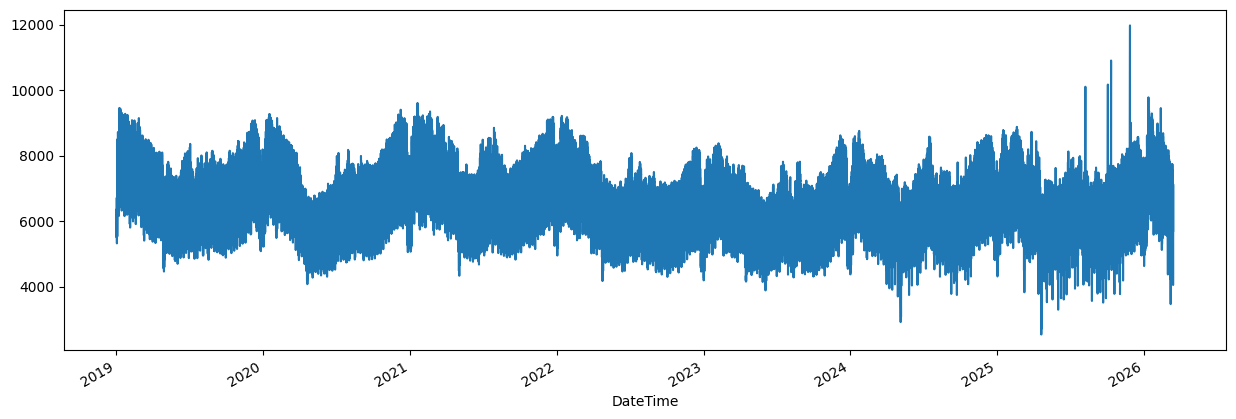

In [56]:
df['Consumption'].plot(figsize=(15,5))

<Axes: xlabel='DateTime'>

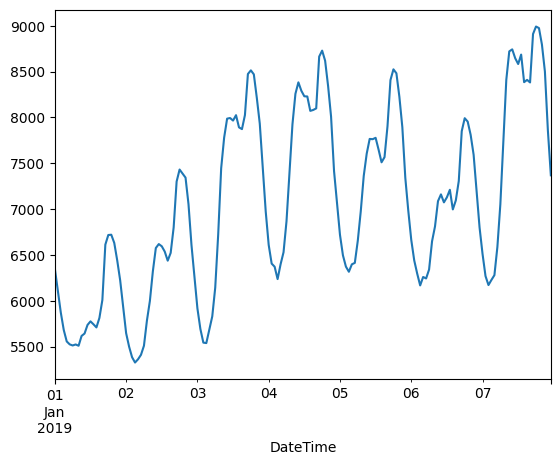

In [57]:
df['Consumption']['2019-01-01':'2019-01-07'].plot()

In [58]:
df['Hour'] = df.index.hour
df['Dayofweek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Imbalance'] = df['Consumption'] - df['Production']
df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Hour,Dayofweek,Month,Imbalance
DateTime,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1,1,-175
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1,1,415
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1,1,197
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1,1,79
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,1,103


<Axes: xlabel='Hour', ylabel='Consumption'>

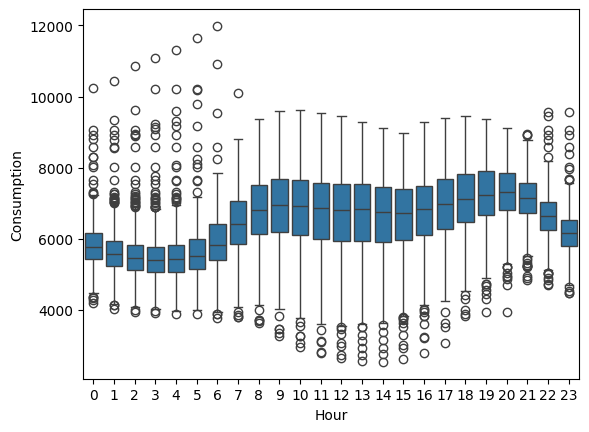

In [59]:
sns.boxplot(x='Hour', y='Consumption', data=df)

<Axes: xlabel='Dayofweek', ylabel='Consumption'>

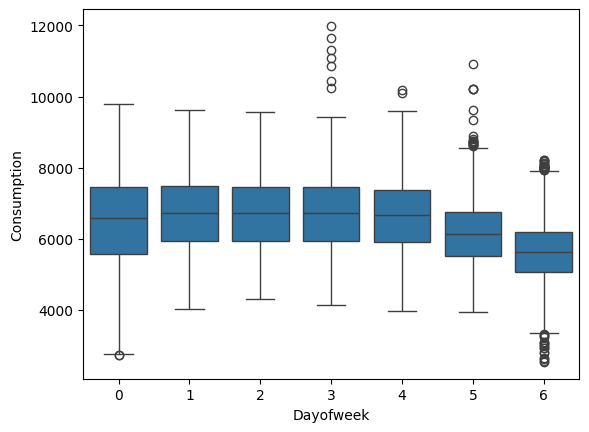

In [60]:
sns.boxplot(x='Dayofweek', y='Consumption', data=df)

## stl

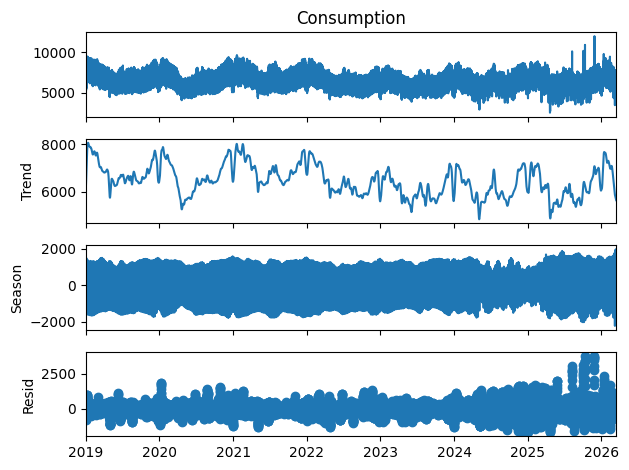

In [61]:
from statsmodels.tsa.seasonal import STL

stl= STL(df['Consumption'], period=24*7)
res = stl.fit()
fig = res.plot()

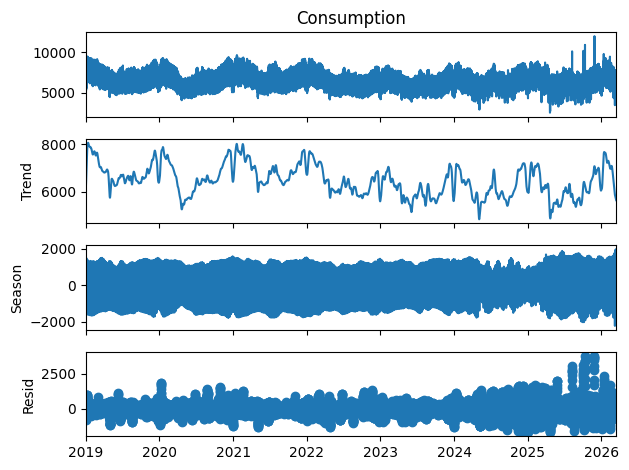

In [62]:
from statsmodels.tsa.seasonal import STL

stl2 = STL(df['Consumption'], period=168)
res2 = stl.fit()
fig2 = res.plot()

## MSTL

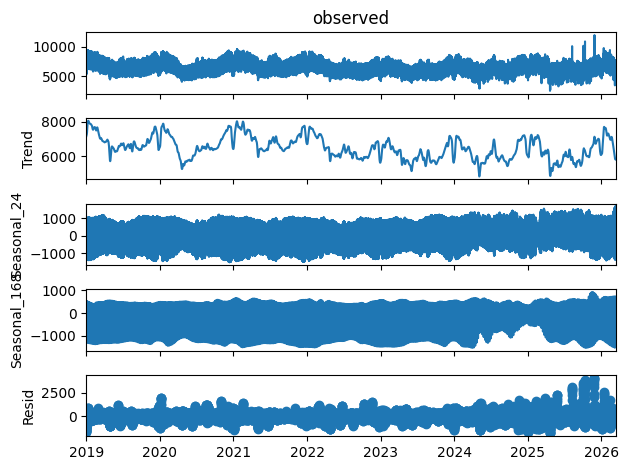

In [63]:
from statsmodels.tsa.seasonal import MSTL
res = MSTL(df['Consumption'], periods=(24, 168)).fit()
fig_res = res.plot()

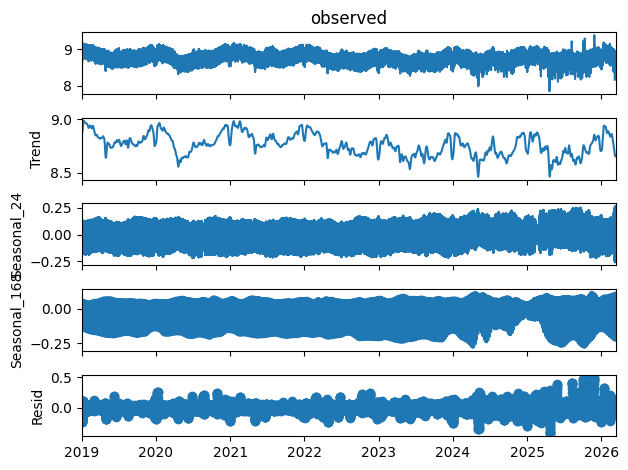

In [72]:
from statsmodels.tsa.seasonal import MSTL
res = MSTL(np.log(df['Consumption']), periods=(24, 168)).fit()
fig_res = res.plot()

### ACF

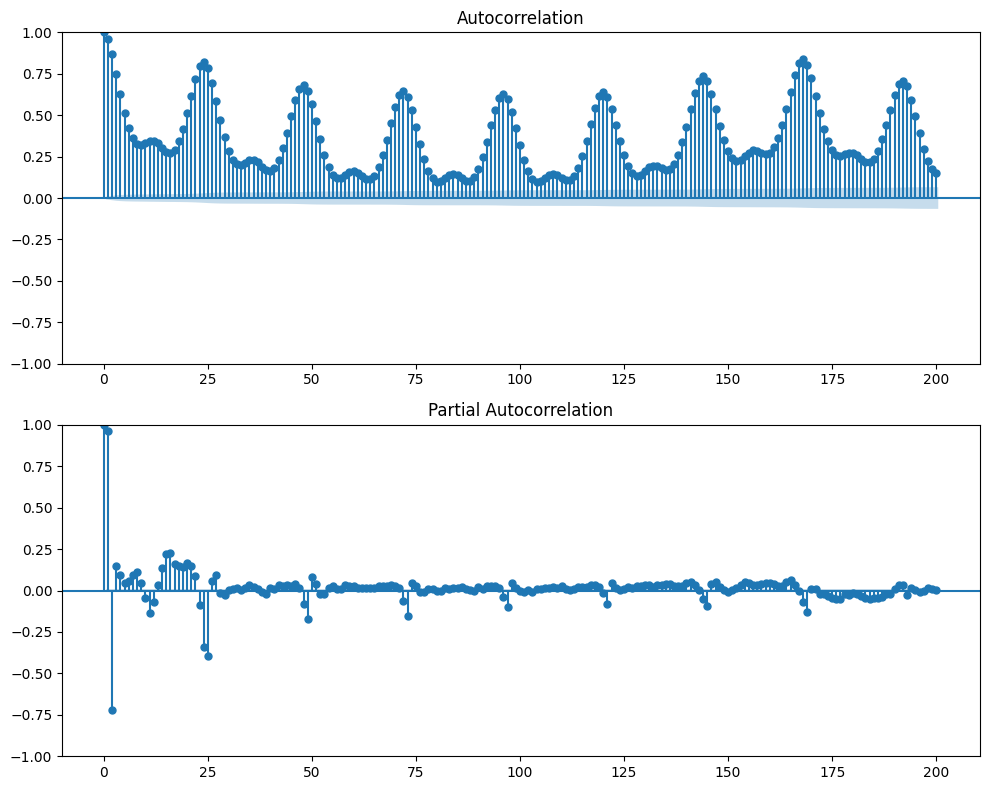

In [64]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10,8))

plot_acf(df['Consumption'], lags=200, ax=ax[0])
plot_pacf(df['Consumption'], lags=200, ax=ax[1])

plt.tight_layout()
plt.show()

In [65]:
diff = df['Consumption'].diff().dropna()

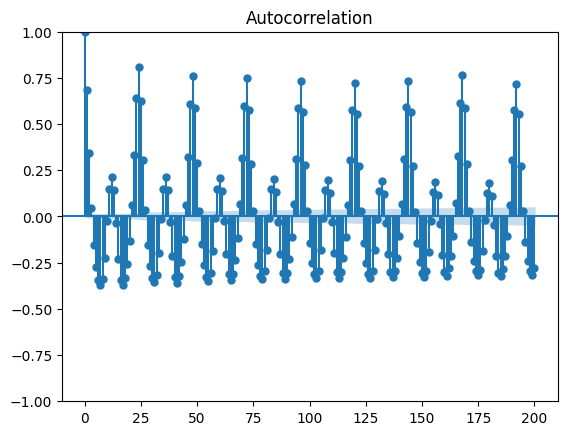

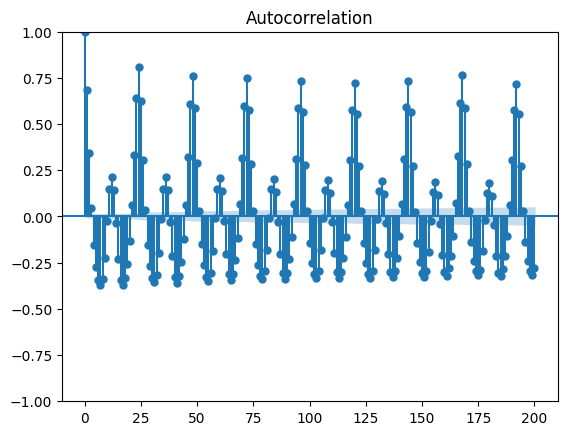

In [66]:
plot_acf(diff, lags=200)


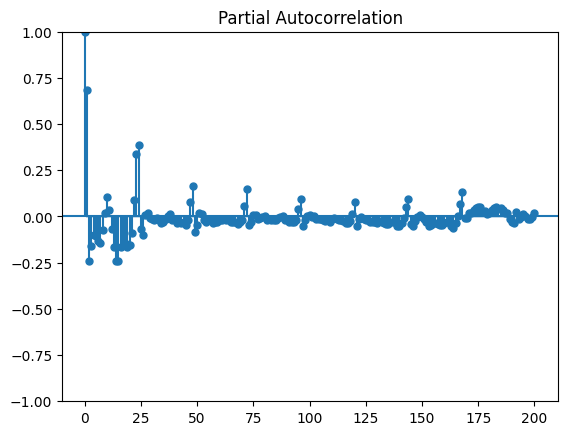

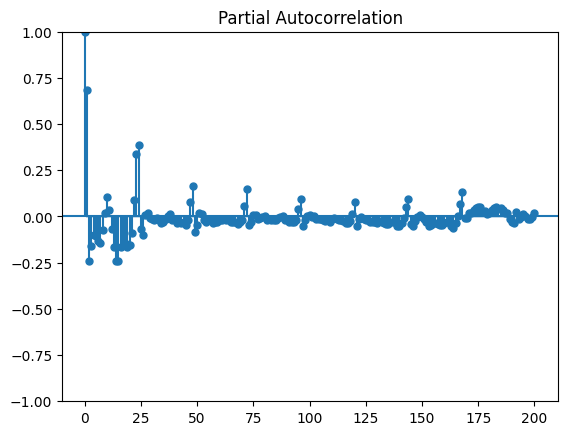

In [67]:
plot_pacf(diff, lags=200)

In [68]:
diff_total = df['Consumption'].diff().diff(24).dropna()

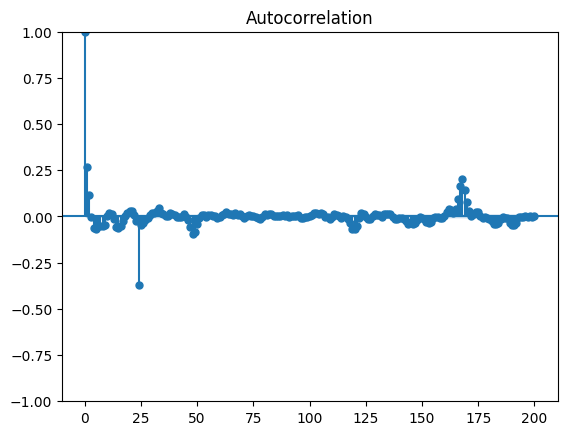

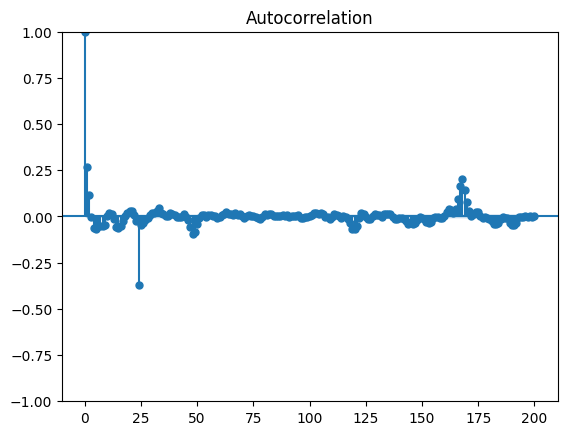

In [69]:
plot_acf(diff_total, lags=200)


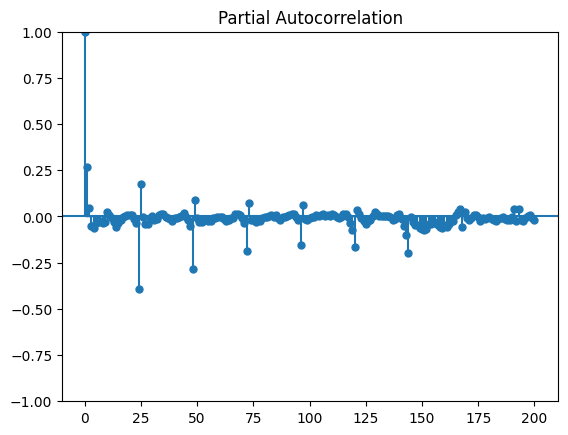

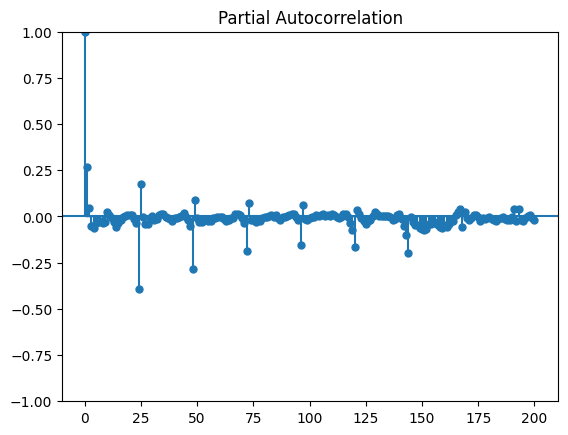

In [70]:
plot_pacf(diff_total, lags=200)


## re-sml con log

In [71]:
series_log = np.log(df)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


## ACF

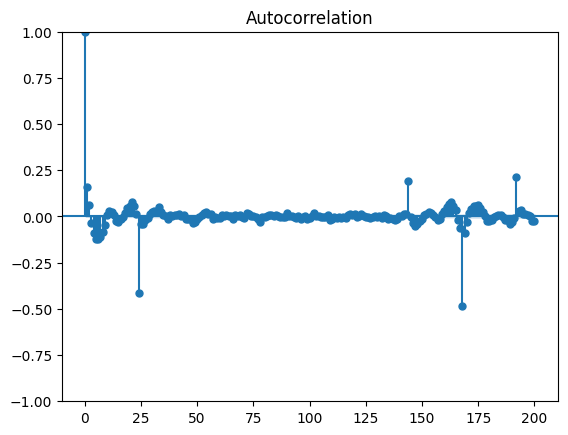

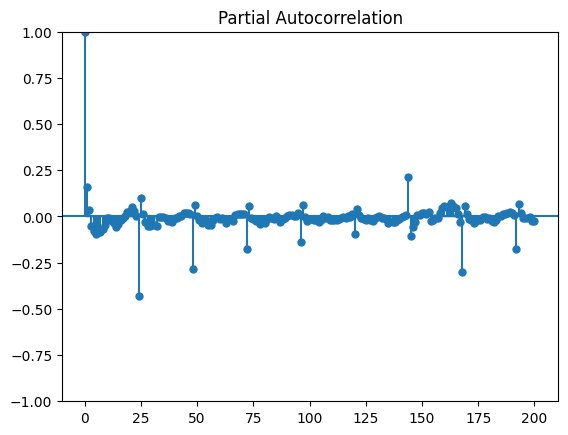

In [78]:
series_diff = np.log(series_log['Consumption']).diff().dropna()
series_diff = series_diff.diff(24).dropna()
series_diff = series_diff.diff(168).dropna()
plot_acf(series_diff, lags=200);
plot_pacf(series_diff, lags=200);

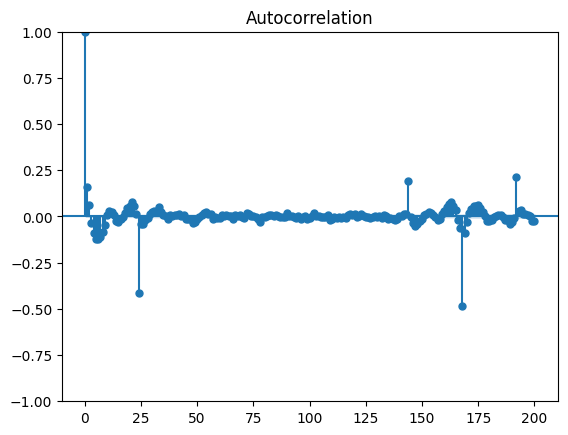

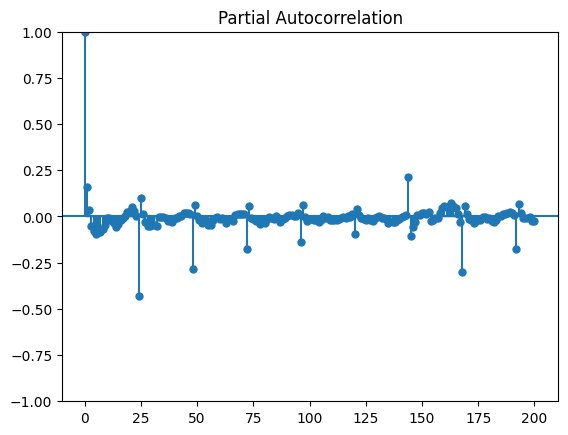

In [85]:
series_diff = np.log(series_log['Consumption']).diff().dropna()
series_diff = series_diff.diff(24).dropna()
series_diff = series_diff.diff(168).dropna()

plot_acf(series_diff, lags=200);
plot_pacf(series_diff, lags=200);

# que siempre hayan picos al aplicar la diferenciacion en 24 y 168 en este casi sugiere (más aun cuando dupliqué lineas), que estoy sobre-diferenciando la serie, pues hasta con poner diff(12) por ejemplo, en el ACF resultante se ve un pico negativo en el valor 12 del eje horizontal, aun habiendo quitado diff(1)

# Codigos

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
y = df['Consumption'].dropna().astype(float)

train_size = int(len(y) * 0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]

In [28]:
# Modelo Naive
naive_pred = np.repeat(train.iloc[-1], len(test))

mae_naive = mean_absolute_error(test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 1055.761104919599
Naive RMSE: 1252.2868721048587


In [29]:
# Modelo SARIMAX (S + ARIMA + X)
model_arima_110 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_110 = model_arima_110.fit(disp=False)
print(results_arima_110.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                50248
Model:               SARIMAX(1, 1, 0)   Log Likelihood             -338324.652
Date:                Sat, 04 Apr 2026   AIC                         676653.305
Time:                        23:59:03   BIC                         676670.954
Sample:                             0   HQIC                        676658.832
                              - 50248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7054      0.003    270.455      0.000       0.700       0.710
sigma2      4.131e+04    169.648    243.503      0.000     4.1e+04    4.16e+04
Ljung-Box (L1) (Q):                2140.13   Jarque-

In [30]:
pred_arima_110 = results_arima_110.forecast(steps=len(test))

mae_arima_110 = mean_absolute_error(test, pred_arima_110)
rmse_arima_110 = np.sqrt(mean_squared_error(test, pred_arima_110))

print("ARIMA(1,1,0) MAE:", mae_arima_110)
print("ARIMA(1,1,0) RMSE:", rmse_arima_110)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA(1,1,0) MAE: 1639.7562683468652
ARIMA(1,1,0) RMSE: 1892.9027412407427


In [31]:
# 2do Modelo SARIMAX (0,1,1)
model_arima_011 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_011 = model_arima_011.fit(disp=False)
print(results_arima_011.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                50248
Model:               SARIMAX(0, 1, 1)   Log Likelihood             -341612.300
Date:                Sat, 04 Apr 2026   AIC                         683228.600
Time:                        23:59:13   BIC                         683246.250
Sample:                             0   HQIC                        683234.128
                              - 50248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6382      0.003    236.716      0.000       0.633       0.643
sigma2       4.71e+04    213.842    220.241      0.000    4.67e+04    4.75e+04
Ljung-Box (L1) (Q):                3530.52   Jarque-

In [32]:
pred_arima_011 = results_arima_011.forecast(steps=len(test))

mae_arima_011 = mean_absolute_error(test, pred_arima_011)
rmse_arima_011 = np.sqrt(mean_squared_error(test, pred_arima_011))

print("ARIMA(0,1,1) MAE:", mae_arima_011)
print("ARIMA(0,1,1) RMSE:", rmse_arima_011)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA(0,1,1) MAE: 1122.1915996613875
ARIMA(0,1,1) RMSE: 1329.3478217115735


In [33]:
model_arima_111 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_111 = model_arima_111.fit(disp=False)
print(results_arima_111.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                50248
Model:               SARIMAX(1, 1, 1)   Log Likelihood             -336721.251
Date:                Sat, 04 Apr 2026   AIC                         673448.502
Time:                        23:59:19   BIC                         673474.976
Sample:                             0   HQIC                        673456.793
                              - 50248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5737      0.005    121.278      0.000       0.564       0.583
ma.L1          0.2935      0.005     58.613      0.000       0.284       0.303
sigma2      3.927e+04    156.914    250.282      0.0

In [34]:
pred_arima_111 = results_arima_111.forecast(steps=len(test))

mae_arima_111 = mean_absolute_error(test, pred_arima_111)
rmse_arima_111 = np.sqrt(mean_squared_error(test, pred_arima_111))

print("ARIMA(1,1,1) MAE:", mae_arima_111)
print("ARIMA(1,1,1) RMSE:", rmse_arima_111)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA(1,1,1) MAE: 1425.6798260757123
ARIMA(1,1,1) RMSE: 1668.674826620882


In [35]:
# Modelo estacionario mínimo, ahora sí con módulo S aplicado
model_sarima_110_010_24 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarima_110_010_24 = model_sarima_110_010_24.fit(disp=False)
print(results_sarima_110_010_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                50248
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 24)   Log Likelihood             -321256.060
Date:                            Sat, 04 Apr 2026   AIC                         642516.121
Time:                                    23:59:47   BIC                         642533.769
Sample:                                         0   HQIC                        642521.648
                                          - 50248                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2945      0.002    145.656      0.000       0.291       0.298
sigma2      2.107e+04     54.128   

In [36]:
pred_sarima_110_010_24 = results_sarima_110_010_24.forecast(steps=len(test))

mae_sarima_110_010_24 = mean_absolute_error(test, pred_sarima_110_010_24)
rmse_sarima_110_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_010_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 18442.342803353396
SARIMA(1,1,0)(0,1,0,24) RMSE: 21220.519173702996


In [37]:
model_sarima_011_010_24 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=False
)

results_sarima_011_010_24 = model_sarima_011_010_24.fit(disp=False, low_memory=True)
print(results_sarima_011_010_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                         Consumption   No. Observations:                50248
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 24)   Log Likelihood             -321638.910
Date:                             Sat, 04 Apr 2026   AIC                         643281.821
Time:                                     23:00:02   BIC                         643299.469
Sample:                                          0   HQIC                        643287.348
                                           - 50248                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2476      0.004     64.154      0.000       0.240       0.255
sigma2      2.143e+04    13

In [38]:
pred_sarima_110_010_24 = results_sarima_110_010_24.forecast(steps=len(test))

mae_sarima_110_010_24 = mean_absolute_error(test, pred_sarima_110_010_24)
rmse_sarima_110_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_010_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 18442.342803353396
SARIMA(1,1,0)(0,1,0,24) RMSE: 21220.519173702996


In [39]:
model_sarima_011_010_24 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_011_010_24 = model_sarima_011_010_24.fit(disp=False, low_memory=True)
print(results_sarima_011_010_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                  D.DS24.Consumption   No. Observations:                50223
Model:             SARIMAX(0, 0, 1)x(0, 0, [], 24)   Log Likelihood             -321639.028
Date:                             Sat, 04 Apr 2026   AIC                         643282.055
Time:                                     23:00:08   BIC                         643299.704
Sample:                                          0   HQIC                        643287.582
                                           - 50223                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2476      0.004     64.152      0.000       0.240       0.255
sigma2      2.143e+04    13

In [40]:
pred_sarima_011_010_24 = results_sarima_011_010_24.forecast(steps=len(test))

mae_sarima_011_010_24 = mean_absolute_error(test, pred_sarima_011_010_24)
rmse_sarima_011_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_011_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_011_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_011_010_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 6282.588270264386
SARIMA(1,1,0)(0,1,0,24) RMSE: 6375.676264731612


In [41]:
model_sarima_111_010_24 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_111_010_24 = model_sarima_111_010_24.fit(disp=False, low_memory=True)
print(results_sarima_111_010_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                  D.DS24.Consumption   No. Observations:                50223
Model:             SARIMAX(1, 0, 1)x(0, 0, [], 24)   Log Likelihood             -321185.815
Date:                             Sat, 04 Apr 2026   AIC                         642377.629
Time:                                     23:00:16   BIC                         642404.102
Sample:                                          0   HQIC                        642385.920
                                           - 50223                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4256      0.011     37.283      0.000       0.403       0.448
ma.L1         -0.1427      

In [42]:
pred_sarima_111_010_24 = results_sarima_111_010_24.forecast(steps=len(test))

mae_sarima_111_010_24 = mean_absolute_error(test, pred_sarima_111_010_24)
rmse_sarima_111_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_111_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_111_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_111_010_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 6282.590103054725
SARIMA(1,1,0)(0,1,0,24) RMSE: 6375.678158581338


In [43]:
model_sarima_110_110_24 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_110_110_24 = model_sarima_110_110_24.fit(disp=False, low_memory=True)
print(results_sarima_110_110_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                 D.DS24.Consumption   No. Observations:                50223
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 24)   Log Likelihood             -316801.550
Date:                            Sat, 04 Apr 2026   AIC                         633609.100
Time:                                    23:00:48   BIC                         633635.571
Sample:                                         0   HQIC                        633617.390
                                          - 50223                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3540      0.004     83.986      0.000       0.346       0.362
ar.S.L24      -0.4013      0.004   

In [44]:
pred_sarima_110_110_24 = results_sarima_110_110_24.forecast(steps=len(test))

mae_sarima_110_110_24 = mean_absolute_error(test, pred_sarima_110_110_24)
rmse_sarima_110_110_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_110_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_110_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_110_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 6282.586414089556
SARIMA(1,1,0)(0,1,0,24) RMSE: 6375.67431921559


In [45]:
model_sarima_111_110_24 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_111_110_24 = model_sarima_111_110_24.fit(disp=False, low_memory=True)
print(results_sarima_111_110_24.summary())

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                  D.DS24.Consumption   No. Observations:                50223
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 24)   Log Likelihood             -316772.591
Date:                             Sat, 04 Apr 2026   AIC                         633553.183
Time:                                     23:01:50   BIC                         633588.478
Sample:                                          0   HQIC                        633564.237
                                           - 50223                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4251      0.010     43.327      0.000       0.406       0.444
ma.L1         -0.0812      

In [46]:
pred_sarima_111_110_24 = results_sarima_111_110_24.forecast(steps=len(test))

mae_sarima_111_110_24 = mean_absolute_error(test, pred_sarima_111_110_24)
rmse_sarima_111_110_24 = np.sqrt(mean_squared_error(test, pred_sarima_111_110_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_111_110_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_111_110_24)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA(1,1,0)(0,1,0,24) MAE: 6282.58668999869
SARIMA(1,1,0)(0,1,0,24) RMSE: 6375.674616207232


In [47]:
results_table = pd.DataFrame({
    'Modelo': [
        'Naive',
        'ARIMA(1,1,0)',
        'ARIMA(0,1,1)',
        'ARIMA(1,1,1)',
        'SARIMA(1,1,0)(0,1,0,24)',
        'SARIMA(0,1,1)(0,1,0,24)',
        'SARIMA(1,1,1)(0,1,0,24)',
        'SARIMA(1,1,0)(1,1,0,24)',
        'SARIMA(1,1,1)(1,1,0,24)'
    ],
    'AIC': [
        np.nan,
        results_arima_110.aic,
        results_arima_011.aic,
        results_arima_111.aic,
        results_sarima_110_010_24.aic,
        results_sarima_011_010_24.aic,
        results_sarima_111_010_24.aic,
        results_sarima_110_110_24.aic,
        results_sarima_111_110_24.aic
    ],
    'MAE': [
        mae_naive,
        mae_arima_110,
        mae_arima_011,
        mean_absolute_error(test, results_arima_111.forecast(steps=len(test))),
        mae_sarima_110_010_24,
        mean_absolute_error(test, results_sarima_011_010_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_111_010_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_110_110_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_111_110_24.forecast(steps=len(test)))
    ]
    ,
    'RMSE': [
        rmse_naive,
        rmse_arima_110,
        rmse_arima_011,
        rmse_arima_111,
        rmse_sarima_110_010_24,
        rmse_sarima_011_010_24,
        rmse_sarima_111_010_24,
        rmse_sarima_110_110_24,
        rmse_sarima_111_110_24
    ]
})

print(results_table.sort_values('MAE'))

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next 

                    Modelo            AIC           MAE          RMSE
0                    Naive            NaN   1055.761105   1252.286872
2             ARIMA(0,1,1)  683228.600281   1122.191600   1329.347822
3             ARIMA(1,1,1)  673448.502119   1425.679826   1668.674827
1             ARIMA(1,1,0)  676653.304690   1639.756268   1892.902741
7  SARIMA(1,1,0)(1,1,0,24)  633609.099621   6282.586414   6375.674319
8  SARIMA(1,1,1)(1,1,0,24)  633553.182904   6282.586690   6375.674616
5  SARIMA(0,1,1)(0,1,0,24)  643282.055281   6282.588270   6375.676265
6  SARIMA(1,1,1)(0,1,0,24)  642377.629411   6282.590103   6375.678159
4  SARIMA(1,1,0)(0,1,0,24)  642516.120947  18442.342803  21220.519174


In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# usa una ventana más manejable para test
test_horizon = 168  # 7 días horarios
train = y.iloc[:-test_horizon].copy()
test = y.iloc[-test_horizon:].copy()

def walk_forward_sarimax(train, test, order, seasonal_order,
                         simple_differencing=False,
                         enforce_stationarity=False,
                         enforce_invertibility=False):
    history = train.copy()
    preds = []

    for t in range(len(test)):
        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            simple_differencing=simple_differencing,
            enforce_stationarity=enforce_stationarity,
            enforce_invertibility=enforce_invertibility
        )
        results = model.fit(disp=False, low_memory=True)

        # 1-step ahead
        yhat = results.forecast(steps=1)
        preds.append(float(yhat.iloc[0]))

        # agregar el valor real al historial
        history = pd.concat([history, test.iloc[t:t+1]])

    preds = pd.Series(preds, index=test.index)
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    return preds, mae, rmse

In [54]:
def walk_forward_naive(train, test):
    history = train.copy()
    preds = []

    for t in range(len(test)):
        preds.append(float(history.iloc[-1]))
        history = pd.concat([history, test.iloc[t:t+1]])

    preds = pd.Series(preds, index=test.index)
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    return preds, mae, rmse

In [50]:
pred_naive, mae_naive, rmse_naive = walk_forward_naive(train, test)
print(mae_naive, rmse_naive)

344.01785714285717 421.55522007375095


In [52]:
pred_arima011, mae_arima011, rmse_arima011 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(0,0,0,0),
    simple_differencing=True
)

c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ignac\Downloads\repo\ProyectoTimeSeries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyboardInterrupt: 

In [53]:
pred_arima011

NameError: name 'pred_arima011' is not defined

In [ ]:
print(mae_arima011, rmse_arima011)

249.68656036377317 314.089359565356


In [ ]:
pred_sarima011, mae_sarima011, rmse_sarima011 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(0,1,0,24),
    simple_differencing=True
)


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

In [ ]:

results_table = pd.DataFrame({
    "Modelo": ["Naive", "ARIMA(0,1,1)", "SARIMA(0,1,1)(0,1,0,24)"],
    "MAE": [mae_naive, mae_arima011, mae_sarima011],
    "RMSE": [rmse_naive, rmse_arima011, rmse_sarima011]
})

print(results_table.sort_values("MAE"))

                    Modelo          MAE         RMSE
1             ARIMA(0,1,1)   249.686560   314.089360
0                    Naive   344.017857   421.555220
2  SARIMA(0,1,1)(0,1,0,24)  5770.148559  5842.701153


In [ ]:
pred_sarima011_10024, mae_sarima011_10024, rmse_sarima011_10024 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(1,0,0,24),
    simple_differencing=True
)


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index w

In [ ]:
print(mae_sarima011_10024, rmse_sarima011_10024)

5771.27065055922 5841.8379151651625


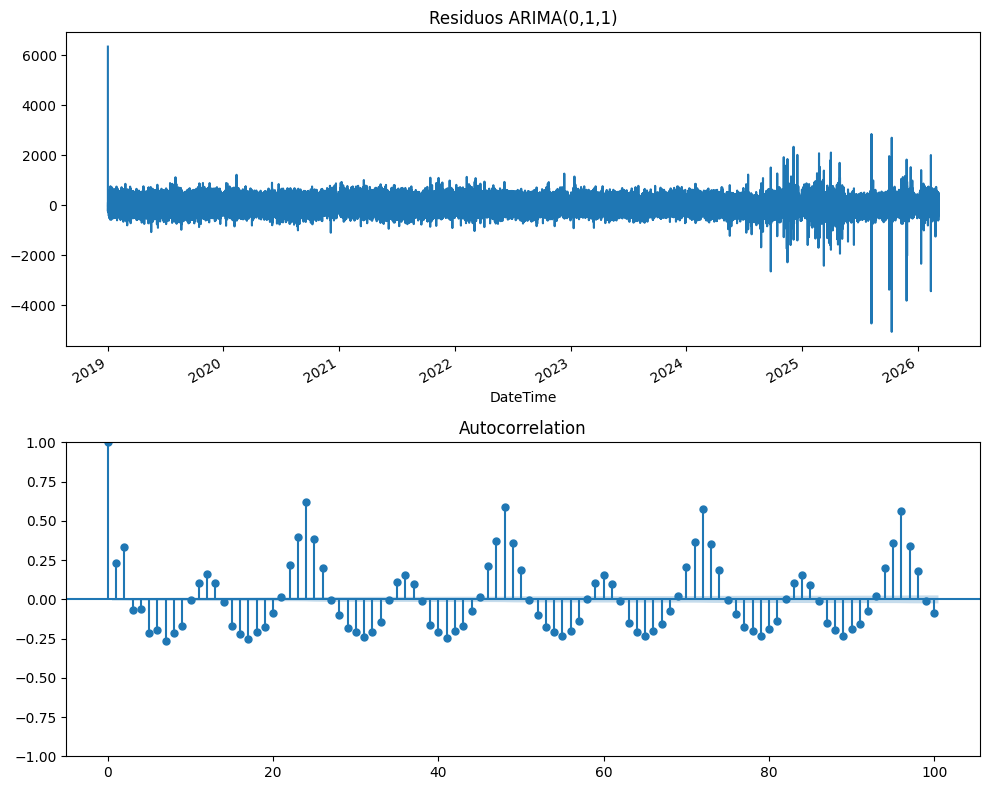

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = results_arima_011.resid.dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
resid.plot(ax=ax[0], title='Residuos ARIMA(0,1,1)')
plot_acf(resid, lags=100, ax=ax[1])
plt.tight_layout()
plt.show()

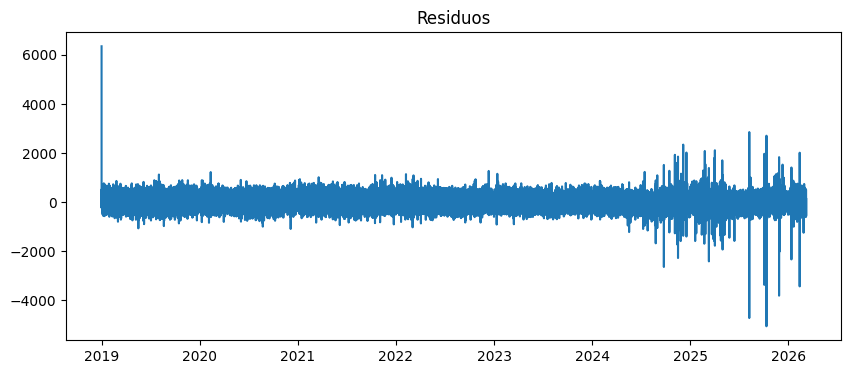

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title("Residuos")
plt.show()

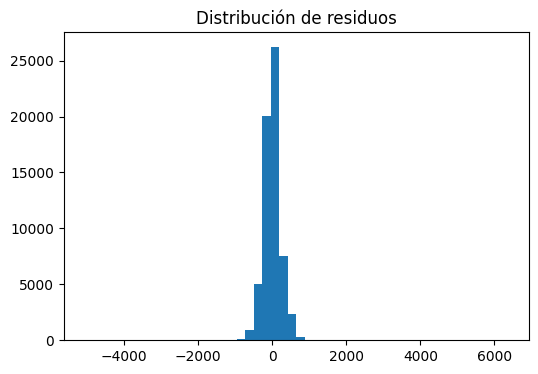

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(resid, bins=50)
plt.title("Distribución de residuos")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(resid, lags=[24], return_df=True)
print(ljung)

         lb_stat  lb_pvalue
24  79224.778022        0.0


In [ ]:
model = SARIMAX(
    train,
    order=(0,1,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results = model.fit(disp=False, low_memory=True)

a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
preds = results.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test, preds)
rmse_sarima = np.sqrt(mean_squared_error(test, preds))

print(mae_sarima, rmse_sarima)

5774.926699103453 5848.554415758872


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


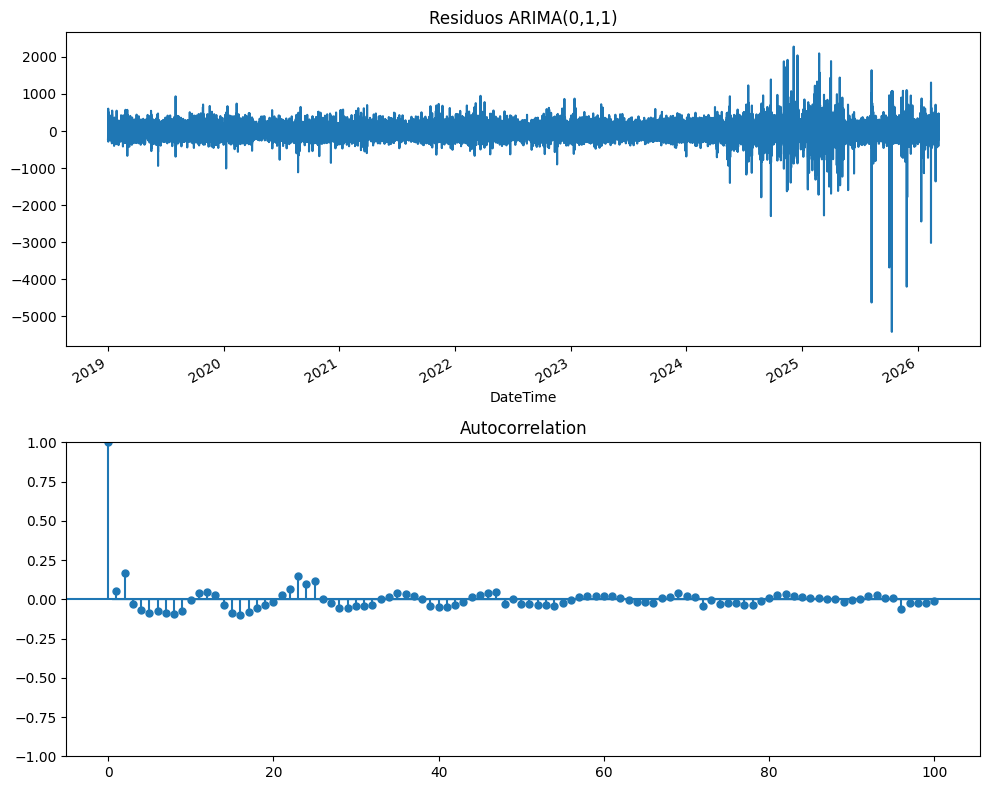

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = results.resid.dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
resid.plot(ax=ax[0], title='Residuos ARIMA(0,1,1)')
plot_acf(resid, lags=100, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(resid, lags=[24], return_df=True)
print(ljung)

        lb_stat  lb_pvalue
24  8843.653695        0.0
